1.	Load a real-world dataset (e.g., tips, penguins, or any CSV you have).
	2.	Choose a numerical variable and a categorical variable with two unique values.
	3.	Formulate the null and alternative hypotheses.
	4.	Check for normality and equal variance assumptions.
	5.	Perform an appropriate hypothesis test (e.g., two-sample t-test or Welch’s t-test).
	6.	Interpret the results in terms of rejecting or failing to reject the null hypothesis.
	7.	Create at least one visual comparison between the two groups (boxplot or histogram).
    

In [7]:
import seaborn as sns
from scipy import stats

In [8]:
df=sns.load_dataset('tips')
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [9]:
df=df.dropna(subset=['sex','tip'])

In [10]:
male_tips=df[df['sex']=='Male']['tip']
female_tips=df[df['sex']=='Female']['tip']

In [14]:
t_stst,p_value=stats.ttest_ind(male_tips,female_tips,equal_var=False)
print(t_stst)
print(p_value)

1.489536377092501
0.13780683808650296


In [15]:
#shaprio test for NORMALITY
shaprio_male=stats.shapiro(male_tips)
shapiro_female=stats.shapiro(female_tips)
print(shapiro_female)
print(shaprio_male)

ShapiroResult(statistic=np.float64(0.9567775372726819), pvalue=np.float64(0.005448280473692281))
ShapiroResult(statistic=np.float64(0.8758690617789388), pvalue=np.float64(3.7084828294513925e-10))


In [17]:
#Equal_variance
levene_test=stats.levene(male_tips,female_tips)
print(levene_test)

LeveneResult(statistic=np.float64(1.9909710178779405), pvalue=np.float64(0.15952363598966177))


In [23]:
#Significance_level(alpha)
a=0.05

if levene_test.pvalue < a:
    t_stat,p_value=stats.ttest_ind(male_tips,female_tips,equal_var=False)
    print('unequal_varience',t_stat,p_value)
else:
    t_stat,p_value=stats.ttest_ind(male_tips,female_tips,equal_var=True)
    print('equal_variance',t_stat,p_value)

equal_variance 1.387859705421269 0.16645623503456755


In [24]:
#there is signifance differnce between male and female tips 


<Axes: xlabel='sex', ylabel='tip'>

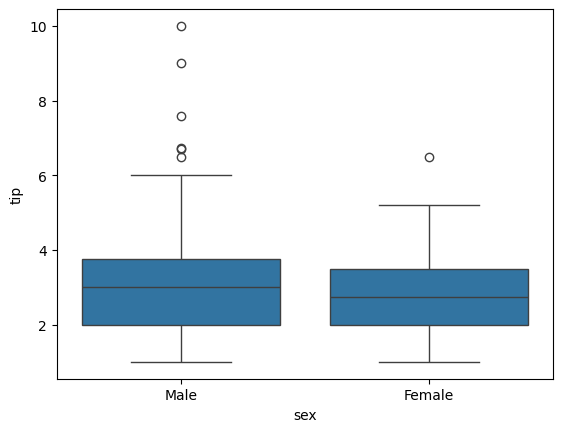

In [27]:
sns.boxplot(x=df['sex'],y=df['tip'])